In [6]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import GoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv


In [7]:
load_dotenv()

True

In [8]:
model = GoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

In [9]:
class LLMState(TypedDict):
    input: str
    output: str

In [10]:
def generate_response(state: LLMState) -> LLMState:
    state['output'] = model.invoke(state['input'])
    return state

In [18]:
graph = StateGraph(LLMState)

graph.add_node('generate_response', generate_response)

graph.add_edge(START, 'generate_response')
graph.add_edge('generate_response', END)

workflow = graph.compile()

In [12]:
initial_state = { 'input': 'What is the capital of France?' }

final_state = workflow.invoke(initial_state)

print(final_state['output'])

The capital of France is **Paris**.


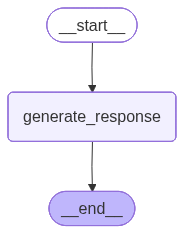

In [13]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())